# fUSI map visualisation tools

This notebook is intended to display maps in fUSI space (Pepe Mariani 2025 space = PIRRAS, Gillian's template, 4 slices $\beta$ \[-3, -2, -1, 0\]mm). The notebook is modular and can serve multiple purposes (requiring adaptation of parameter loading and function calls). It was designed and is overfit for Seed Based Maps (SBM) display, so default use is based on ROIs list, the last section deal with list of files without ROIs. Images are loaded in fUSI low resolution (4 slices in plane 100x110 $\mu m$). Images are then resampled in high resolution space (4 slices in plane 25x25 $\mu m$) estimated by the neuronavigation script for display.

First section is dedicated to environment management:
- packages import
- colormap loading (blue-to-red, derived from graphpad)
- parameter loading
    - rois file (optional, required for seed based maps)
 
Second section is dedicated to low resolution 
- first sub section deals with a single file to ensure proper setup of the environment
- second section loops to generate multiple figures of the low res images

Third section is dedicated to high resolution display
- It follows the same structure as the previous section
- Options to display untrhesholded maps is also proposed

Last section proposes display of high res map without ROIs
- example given is for CAPs, but could be generalised to any map (under reasonable adaptation of display parameters)

# Environment management

In [2]:
import re

import numpy as np
import nibabel as nib
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pathlib import Path
from tqdm import tqdm

from nilearn.masking import apply_mask, unmask
from nilearn.image import resample_img
from scipy.ndimage import gaussian_filter, binary_fill_holes, binary_dilation

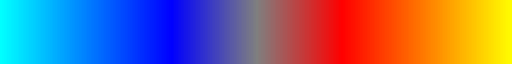

In [5]:
# Loading the FSL colourmap

cmap_name = '../libraries/colourmaps/render3.cmap'

with open(cmap_name, 'r') as f:
    
    lines = f.readlines()
    
cmap_list = [[float(y) for y in x.split('\n')[0].split(' ')] for x in lines]

mymap = mcolors.ListedColormap(cmap_list)
mymap

In [81]:
# Parameters

# display parameters

nb_lin = 1
nb_col = 4

# image parameters

template_lr_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-110umx100umx100um_pose-vol_feature.nii.gz')
template_lr_img = nib.load(template_lr_name)

template_hr_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/pose-template/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-25umx25umx25um_pose-vol_feature.nii.gz')
template_hr_img = nib.load(template_hr_name)

# root for ROIs (if applies)
roi_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/parcellations/parcellationUnilateralDefaultN54/whole-ROI_CP-20/00_left_single-slice/')
# root for images
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/01_SBA/2025-07-08_single-slice/CPT-unilateral/01_group_maps/REGaCompCor/')

parcellation_tag = 'parcellationUnilateralDefaultN54'
roi_type = 'Left-singleSlice'

acro_list = []
roi_list = []
file_list = []

# lists ROIs and find associated images

for roi_name in sorted(roi_root.iterdir()):
    if roi_name.is_file():
        
        roi_list.append(roi_name)
        acro_list.append(roi_name.name.split(f'{parcellation_tag}-')[1].split(f'-{roi_type}')[0])

        file_name = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*{acro_list[-1]}.*Tstat_cc_t2.1_p0.05.nii.gz$', x.name)])[0]
        file_list.append(file_name)

print(f'nb ROIs: {len(roi_list)}\n')

for roi_name in roi_list:
    print(f'{roi_name.name}')

print(f'\nnb images: {len(file_list)}\n')

for file_name in file_list:
    print(f'{file_name.name}')

save_dir = Path('/media/DATA2/JC/3_Trash/2025-10-27_high-res-display_refactoring/')
save_dir.mkdir(exist_ok = True, parents = True)

nb ROIs: 21

parcellationUnilateralDefaultN54-ROI-1-MOp-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-10-SSs-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-15-AUDv-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-18-VISp-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-19-AIp-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-2-MOs-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-22-ACA-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-23-RSPd-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-24-RSPv-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-25-PTLp-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-29-PIR-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-30-COA-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-32-CA-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-ROI-33-DG-Left-singleSlice.nii.gz
parcellationUnilateralDefaultN54-R

# Low res

In [82]:
def low_res_display(
    img,
    template_lr_img,
    roi_img = None,
    title = None,
    nb_lin = 1,
    nb_col = 4,
    dpi = 200,
    slice_ids = range(4),
    aspect = 0.1/0.11,
    template_cmap = 'Greys_r',
    img_cmap = mymap,
    alpha_transp = 0.7,
    vmin = 2.1,
    vmax = 8
):

    fig, ax = plt.subplots(
        nb_lin, nb_col, figsize=(7*nb_col, 5*nb_lin), dpi = dpi, facecolor = 'k'
    )
    
    for slice_id in slice_ids:
    
        img_2_display = template_lr_img.get_fdata()[slice_id,:,:]
        ax[-1-slice_id].imshow(img_2_display, aspect = aspect, cmap = template_cmap)
        
        img_2_display = img.get_fdata()[slice_id,:,:]
        alpha = abs(img_2_display) > vmin
        ax[-1-slice_id].imshow(img_2_display, aspect = aspect, cmap = img_cmap, vmin = -vmax, vmax = vmax, alpha = alpha_transp*alpha)

        if roi_img is not None:
        
            img_2_display = roi_img.get_fdata()[slice_id,:,:]
            ax[-1-slice_id].contour(img_2_display, levels = [0.5], colors = ['k'])
            
        ax[-1-slice_id].axis('off')

    if title is not None:
        
        plt.suptitle(f'{title}', c = 'w', fontsize = 25)
    
    plt.tight_layout()

    return fig, ax

## Single file

In [83]:
file_id = 12

roi_acro = acro_list[file_id]

file_name = file_list[file_id]
img = nib.load(file_name)

roi_name = roi_list[file_id]
roi_img = nib.load(roi_name)

# symmetrical (-vmax -vmin vmin vmax) display parameters

vmin = 2.1
vmax = 8

alpha_transp = 0.7                          # map overall transparency

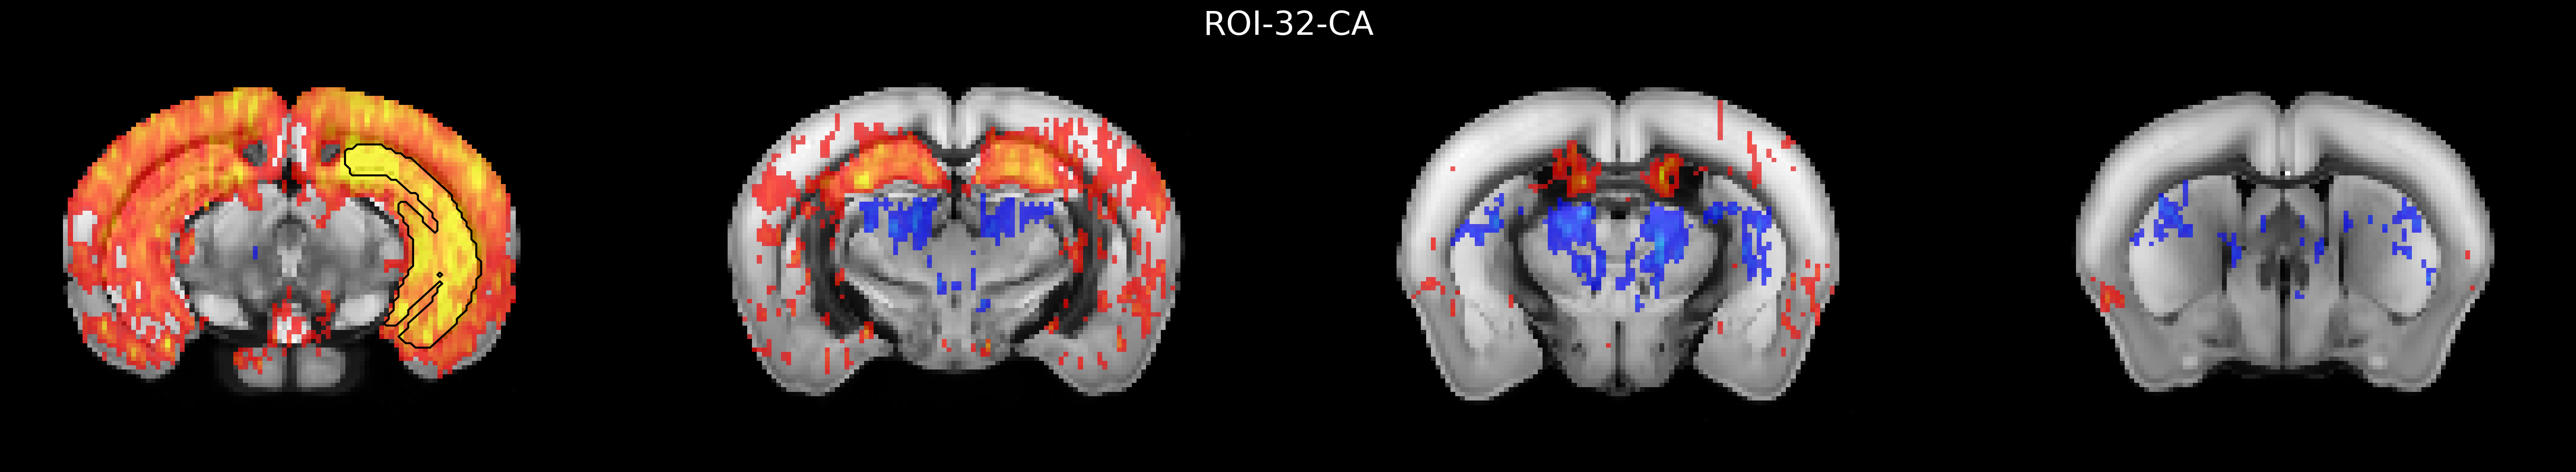

In [84]:
fig, ax = low_res_display(
    img,
    template_lr_img,
    roi_img = roi_img,
    title = roi_acro,
    nb_lin = nb_lin,
    nb_col = nb_col,
    vmin = vmin,
    vmax = vmax
)

## Loop

In [85]:
# symmetrical (-vmax -vmin vmin vmax) display parameters

vmin = 2.1
vmax = 8

alpha_transp = 0.7                          # map overall transparency

In [86]:
for roi_acro, file_name, roi_name in tqdm(zip(acro_list, file_list, roi_list)):

    img = nib.load(file_name)
    
    roi_img = nib.load(roi_name)

    fig, ax = low_res_display(
        img,
        template_lr_img,
        roi_img = roi_img,
        title = roi_acro,
        nb_lin = nb_lin,
        nb_col = nb_col,
        vmin = vmin,
        vmax = vmax
    )

    save_name = save_dir / '00_low_res' / f'{roi_acro}_low-res-map_vlim-{str(vmin).replace('.', 'p')}-{str(vmax).replace('.', 'p')}.png'
    save_name.parent.mkdir(exist_ok = True, parents = True)

    plt.savefig(save_name)

    plt.close('all')

21it [00:31,  1.51s/it]


# High Res

In [133]:
def high_res_display(
    highres_img,
    template_hr_img,
    highres_roi = None,
    nb_lin = 1,
    nb_col = 4,
    dpi = 200,
    slice_ids = range(4),
    aspect = 0.1/0.1,
    template_cmap = 'Greys_r',
    img_cmap = mymap,
    template_vmin = 10,
    template_vmax = 270,
    img_vmin = 2.1,
    img_vmax = 8,
    template_th = 10,
    alpha_transp = 0.7,
    interpolation = 'gaussian'
):  
    
    fig, ax = plt.subplots(
        nb_lin, nb_col, figsize=(6*nb_col, 5*nb_lin), dpi = dpi, facecolor = 'w'
    )
    
    for slice_id in slice_ids:
    
        img_2_display = template_hr_img.get_fdata()[slice_id,:,:]
        mask = binary_fill_holes(img_2_display>template_th)
        ax[-slice_id-1].imshow(img_2_display, aspect = aspect, vmin = template_vmin, vmax = template_vmax, cmap = template_cmap, alpha = 1.*mask)
        
        img_2_display = highres_img.get_fdata()[slice_id,:,:]
        if interpolation == 'gaussian':
            img_2_display = gaussian_filter(img_2_display, sigma=4)
            alpha = (abs(img_2_display) > img_vmin)*mask
        elif interpolation == 'nearest':
            alpha = mask.copy()
        else:
            print('Error invalid interpolation, accepted value: "gaussian" or "nearest"')
            
        ax[-slice_id-1].imshow(img_2_display, aspect = aspect, cmap = img_cmap, vmin = -img_vmax, vmax = img_vmax, alpha = alpha_transp*alpha)

        if not (highres_roi is None):
            
            img_2_display = highres_roi.get_fdata()[slice_id,:,:]
            img_2_display = gaussian_filter(img_2_display, sigma=4)
            img_2_display[img_2_display<0.50] = 0
            ax[-slice_id-1].contour(img_2_display, levels = [0.5], colors = ['k'], linewidths = [2])
    
        img_2_display = mask.copy()
        img_2_display = binary_dilation(img_2_display, iterations=2)
        img_2_display = (gaussian_filter(img_2_display, sigma = .4)>0.9)
        ax[-slice_id-1].contour(img_2_display, levels = [0.5], colors = ['k'], linewidths = [4])
        
        ax[-slice_id-1].axis('off')
    
    plt.tight_layout()

    return fig, ax

## Classical display

In [110]:
# fMRI
# img_vmin = 5
# img_vmax = 12
# processing = 'acq-3dscan'
# regimen = 'fMRI'

# root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/02_fMRI/First-pass/derivatives/SBM/results/second-pass_single-slice_unilateral_n29/01_group_maps/acq-3dscan/')

# fUSI
img_vmin = 2.1
img_vmax = 8
processing = 'REGaCompCor'
regimen = 'CPT-unilateral'

root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/01_SBA/2025-07-08_single-slice/{regimen}/01_group_maps/{processing}')

file_list = []

# lists ROIs and find associated images

for roi_name in sorted(roi_root.iterdir()):
    if roi_name.is_file():

        file_name = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*{roi_name.name.split(f'{parcellation_tag}-')[1].split(f'-{roi_type}')[0]}.*Tstat_cc_t2.1_p0.05.nii.gz$', x.name)])[0]
        file_list.append(file_name)

print(f'\nnb images: {len(file_list)}\n')

for file_name in file_list:
    print(f'{file_name.name}')

[X,Y,Z] = template_hr_img.shape
vmin = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].min()
vmax = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].max()

save_folder = save_dir / '01_high_res' / Path(f'2025-07-14_unilateralLeft_singleSlice_contour4_{regimen}_vminvmax-{str(img_vmin).replace('.', 'p')}-{str(img_vmax).replace('.', 'p')}')
save_folder.mkdir(parents = True, exist_ok = True)

print(f'\n\nResults will be saved in: \n{save_folder}')


nb images: 21

REGaCompCor_parcellationUnilateralDefaultN54-ROI-1-MOp-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-10-SSs-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-15-AUDv-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-18-VISp-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-19-AIp-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-2-MOs-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-22-ACA-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-23-RSPd-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-24-RSPv-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05

### Single file

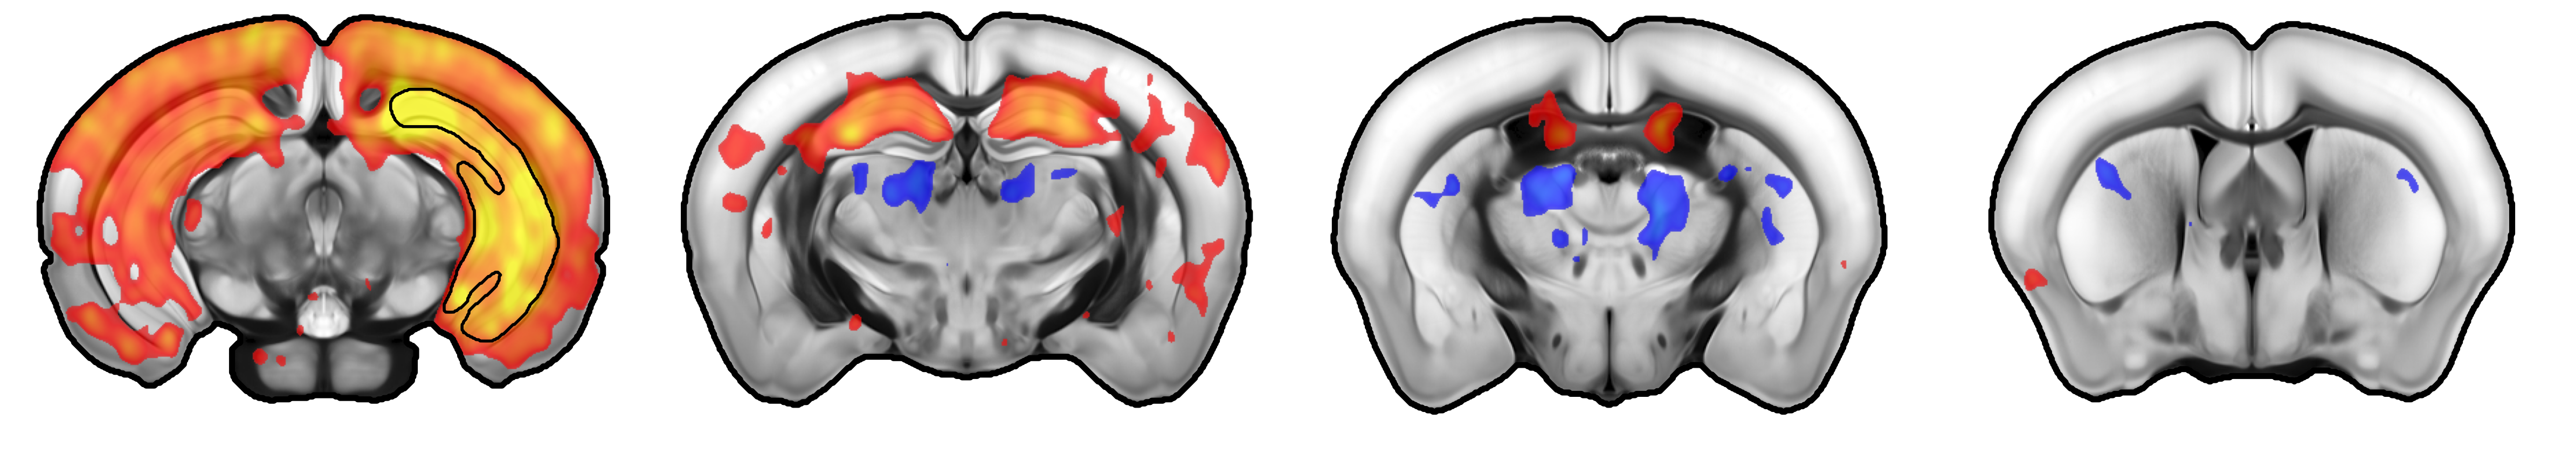

In [113]:
file_id = 12

roi_acro = acro_list[file_id]
file_name = file_list[file_id]
roi_name = roi_list[file_id]

img = nib.load(file_name)

highres_img = resample_img(
        img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        copy_header=True,
        force_resample=True
    )

roi_img = nib.load(roi_name)
    
highres_roi = resample_img(
    roi_img,
    target_affine = template_hr_img.affine,
    target_shape = template_hr_img.shape,
    interpolation='nearest',
    copy_header=True,
    force_resample=True
)

fig, ax = high_res_display(
    highres_img,
    template_hr_img,
    highres_roi = highres_roi,
    template_vmin = vmin,
    template_vmax = vmax,
    img_vmin = img_vmin,
    img_vmax = img_vmax
)

### Loop

In [103]:
for roi_acro, file_name, roi_name in tqdm(zip(acro_list, file_list, roi_list)):
    
    img = nib.load(file_name)
    
    highres_img = resample_img(
            img,
            target_affine = template_hr_img.affine,
            target_shape = template_hr_img.shape,
            copy_header=True,
            force_resample=True
        )
    
    roi_img = nib.load(roi_name)
        
    highres_roi = resample_img(
        roi_img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        interpolation='nearest',
        copy_header=True,
        force_resample=True
    )

    fig, ax = high_res_display(
        highres_img,
        template_hr_img,
        highres_roi = highres_roi,
        template_cmap = 'Greys_r',
        img_cmap = mymap,
        template_vmin = vmin,
        template_vmax = vmax,
        img_vmin = img_vmin,
        img_vmax = img_vmax
    )

    save_name = save_folder / '01_high_res' / Path(f'2{roi_acro}_{regimen}_{processing}_vminvmax-{str(img_vmin).replace('.', 'p')}-{str(img_vmax).replace('.', 'p')}.png')
    save_name.parent.mkdir(exist_ok = True, parents = True)
    plt.savefig(
        save_name
    )

    save_name = save_name.parent / save_name.name.replace('.png', '.svg')
    plt.savefig(
        save_name
    )

    plt.close('all')

21it [02:38,  7.53s/it]


## Unthresholded

In [118]:
# display params

slice_ids = np.arange(4)

# fMRI
# img_vmin = 5
# img_vmax = 12
# processing = 'acq-3dscan'
# regimen = 'fMRI'

# root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/02_fMRI/First-pass/derivatives/SBM/results/second-pass_single-slice_unilateral_n29/01_group_maps/acq-3dscan/')

# fUSI
img_vmin = 0.
img_vmax = 0.5
processing = 'REGaCompCor'
regimen = 'CPT-unilateral'

root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/01_SBA/2025-07-08_single-slice/{regimen}/01_group_maps/{processing}')

file_list = []
th_list = []

# lists ROIs and find associated images

for roi_name in sorted(roi_root.iterdir()):
    if roi_name.is_file():

        file_name = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*{roi_name.name.split(f'{parcellation_tag}-')[1].split(f'-{roi_type}')[0]}.*mean_diff.nii.gz$', x.name)])[0]
        file_list.append(file_name)
        
        th_name = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*{roi_name.name.split(f'{parcellation_tag}-')[1].split(f'-{roi_type}')[0]}.*Tstat_cc_t2.1_p0.05.nii.gz$', x.name)])[0]
        th_list.append(th_name)

print(f'\nnb images: {len(file_list)}\n')

for file_name in file_list:
    print(f'{file_name.name}')

print(f'\nnb th masks: {len(file_list)}\n')

for th_name in th_list:
    print(f'{th_name.name}')

[X,Y,Z] = template_hr_img.shape
vmin = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].min()
vmax = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].max()

save_folder = save_dir / '01_high_res' / Path(f'2025-07-14_unilateralLeft_singleSlice_contour4_{regimen}_vminvmax-{str(img_vmin).replace('.', 'p')}-{str(img_vmax).replace('.', 'p')}_unthrehsolded')
save_folder.mkdir(parents = True, exist_ok = True)

print(f'\n\nResults will be saved in: \n{save_folder}')


nb images: 21

REGaCompCor_parcellationUnilateralDefaultN54-ROI-1-MOp-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-10-SSs-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-15-AUDv-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-18-VISp-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-19-AIp-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-2-MOs-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-22-ACA-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-23-RSPd-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-24-RSPv-Left-singleSlice_onesample_mean_diff.nii.gz
REGaCompCor_parcellationUnilateralDefaultN54-ROI-25-PTLp-Left-singleSlice_onesampl

### Single file

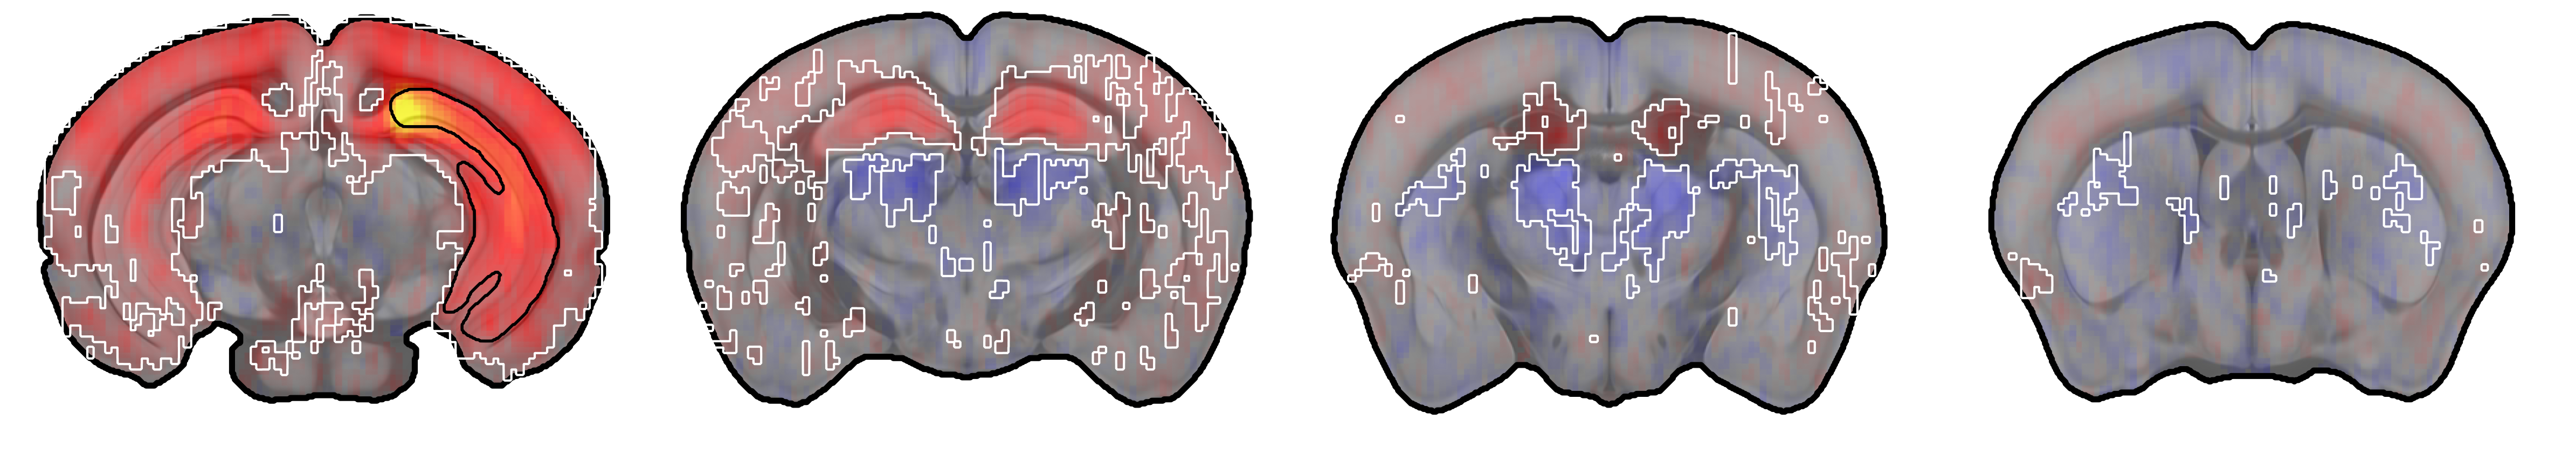

In [121]:
file_id = 12

roi_acro = acro_list[file_id]
file_name = file_list[file_id]
roi_name = roi_list[file_id]
th_name = th_list[file_id]

img = nib.load(file_name)

highres_img = resample_img(
        img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        copy_header=True,
        force_resample=True,
        interpolation='nearest'
    )

roi_img = nib.load(roi_name)
    
highres_roi = resample_img(
    roi_img,
    target_affine = template_hr_img.affine,
    target_shape = template_hr_img.shape,
    interpolation='nearest',
    copy_header=True,
    force_resample=True
)

th_img = nib.load(th_name)
    
highres_th = resample_img(
    th_img,
    target_affine = template_hr_img.affine,
    target_shape = template_hr_img.shape,
    interpolation='nearest',
    copy_header=True,
    force_resample=True
)

fig, ax = high_res_display(
    highres_img,
    template_hr_img,
    highres_roi = highres_roi,
    template_vmin = vmin,
    template_vmax = vmax,
    img_vmin = img_vmin,
    img_vmax = img_vmax,
    interpolation = 'nearest'
)

for slice_id in slice_ids:

    ax[-1-slice_id].contour(abs(highres_th.get_fdata())[slice_id, :, :], levels = [0.5], colors = ['w'])

In [122]:
for file_name, roi_name, th_name, roi_acro in tqdm(zip(file_list, roi_list, th_list, acro_list)):

    img = nib.load(file_name)
    
    highres_img = resample_img(
            img,
            target_affine = template_hr_img.affine,
            target_shape = template_hr_img.shape,
            copy_header=True,
            force_resample=True,
            interpolation='nearest'
        )
    
    roi_img = nib.load(roi_name)
        
    highres_roi = resample_img(
        roi_img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        interpolation='nearest',
        copy_header=True,
        force_resample=True
    )
    
    th_img = nib.load(th_name)
        
    highres_th = resample_img(
        th_img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        interpolation='nearest',
        copy_header=True,
        force_resample=True
    )
    
    fig, ax = high_res_display(
        highres_img,
        template_hr_img,
        highres_roi = highres_roi,
        template_vmin = vmin,
        template_vmax = vmax,
        img_vmin = img_vmin,
        img_vmax = img_vmax,
        interpolation = 'nearest'
    )
    
    for slice_id in slice_ids:
    
        ax[-1-slice_id].contour(abs(highres_th.get_fdata())[slice_id, :, :], levels = [0.5], colors = ['w'])

    save_name = save_folder / '02_unthresholded' / Path(f'{roi_acro}_{regimen}_{processing}_vminvmax-{str(img_vmin).replace('.', 'p')}-{str(img_vmax).replace('.', 'p')}.png')
    save_name.parent.mkdir(exist_ok = True, parents = True)
    plt.savefig(
        save_name
    )

    save_name = save_name.parent / save_name.name.replace('.png', '.svg')
    plt.savefig(
        save_name
    )

    plt.close('all')

21it [02:24,  6.88s/it]


## No ROIs

In [131]:
root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/04_CAPs/2025-07-28_reanalysis_CAPs/00_scripts/2025-09-03_Second-Pass/00_results/fus-caps_parcel_CPT_plus_analysis/cap_maps_lowres_k6/')

file_list = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^CPT_T_cap_.*.nii.gz$', x.name)])

print(f'We found {len(file_list)} files\n')

for file_name in file_list:

    print(file_name.name)

img_vmin = 8
img_vmax = 32

[X,Y,Z] = template_hr_img.shape
vmin = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].min()
vmax = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].max()


We found 6 files

CPT_T_cap_1.nii.gz
CPT_T_cap_2.nii.gz
CPT_T_cap_3.nii.gz
CPT_T_cap_4.nii.gz
CPT_T_cap_5.nii.gz
CPT_T_cap_6.nii.gz


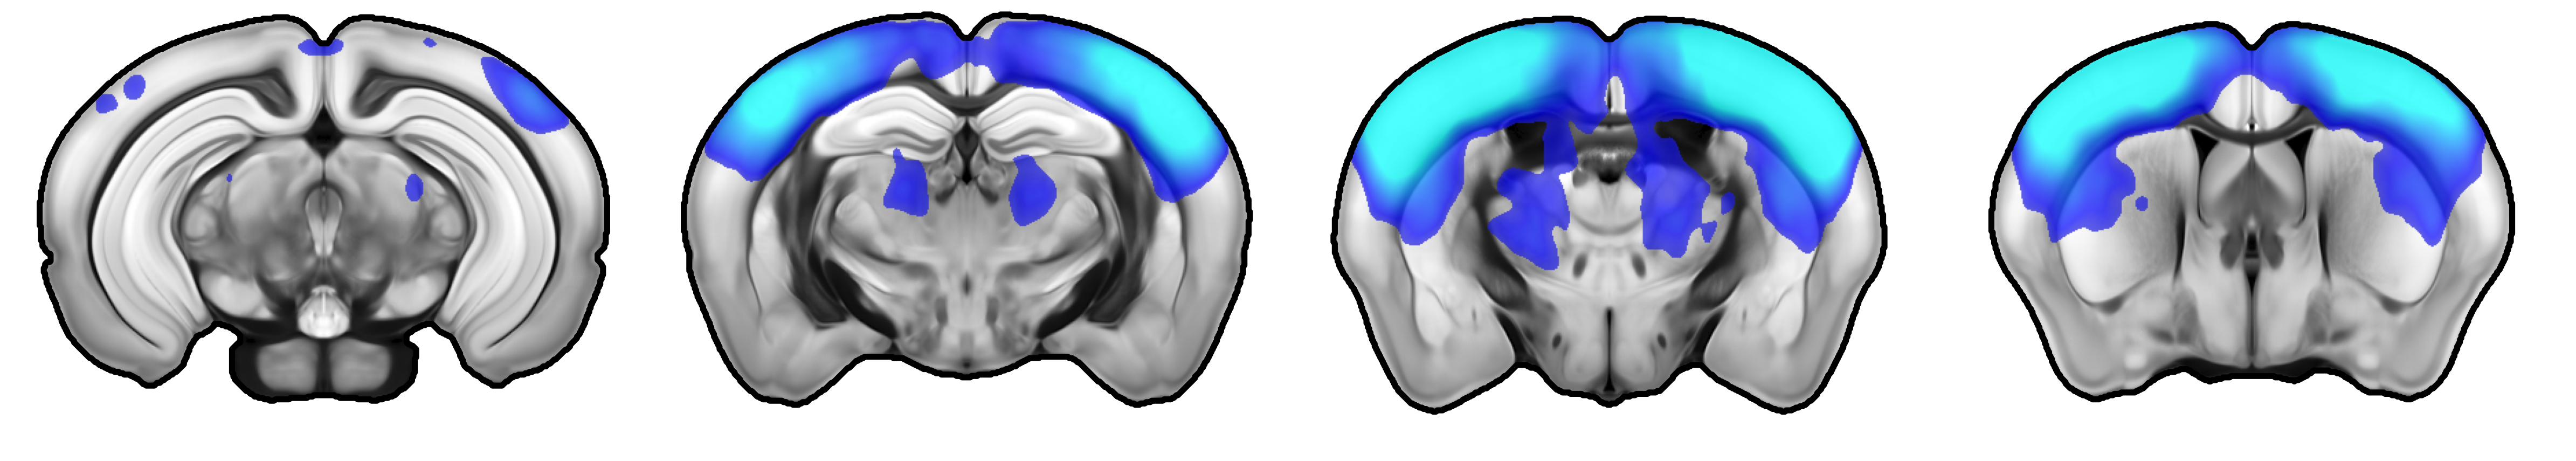

In [140]:
file_id = 2

file_name = file_list[file_id]

# MATLAB orientation is messed up

img = nib.load(file_name)
new_affine = img.affine.copy()
new_affine[1,0] = -1
img = nib.Nifti1Image(
    img.get_fdata(),
    affine = new_affine
)

highres_img = resample_img(
        img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        copy_header=True,
        force_resample=True
    )

fig, ax = high_res_display(
    highres_img,
    template_hr_img,
    highres_roi = None,
    template_vmin = vmin,
    template_vmax = vmax,
    img_vmin = img_vmin,
    img_vmax = img_vmax
)

In [ ]:
for file_name in tqdm(file_list):
    
    # MATLAB orientation is messed up
    
    img = nib.load(file_name)
    new_affine = img.affine.copy()
    new_affine[1,0] = -1
    img = nib.Nifti1Image(
        img.get_fdata(),
        affine = new_affine
    )
    
    highres_img = resample_img(
            img,
            target_affine = template_hr_img.affine,
            target_shape = template_hr_img.shape,
            copy_header=True,
            force_resample=True
        )
    
    fig, ax = high_res_display(
        highres_img,
        template_hr_img,
        highres_roi = None,
        template_vmin = vmin,
        template_vmax = vmax,
        img_vmin = img_vmin,
        img_vmax = img_vmax
    )

    save_name = save_folder / '03_noROIs' / Path(f'{file_name.name.split('.nii.gz')[0]}_vminvmax-{str(img_vmin).replace('.', 'p')}-{str(img_vmax).replace('.', 'p')}.png')
    save_name.parent.mkdir(exist_ok = True, parents = True)
    plt.savefig(
        save_name
    )

    save_name = save_name.parent / save_name.name.replace('.png', '.svg')
    plt.savefig(
        save_name
    )

    plt.close('all')

 17%|████████████████████▎                                                                                                     | 1/6 [00:07<00:37,  7.53s/it]

# Supplementary

## stable version 2025-10-27

In [ ]:
# fMRI
# th = 5
# img_vmax = 12
# processing = 'acq-3dscan'
# regimen = 'fMRI'

# fUSI
th = 2.1
img_vmax = 8
processing = 'REGaCompCor'
regimen = 'CPT'


# fUSI
# root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/01_SBA/2025-07-08_single-slice/{regimen}/01_group_maps/')
root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/01_SBA/2025-07-08_single-slice/CPT-unilateral/01_group_maps/')

# fMRI
# root_path = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/03_analyses/02_fMRI/derivatives/SBM/results/singleslice_left/01_group_maps/')

[X,Y,Z] = template_hr_img.shape
vmin = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].min()
vmax = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].max()

save_dir = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/04_figures/figure_2/SBM/2025-10-13_unilateral_singleSlice_contour4_{regimen}_vminvmax-{str(th).replace('.', 'p')}-{img_vmax}')
save_dir.mkdir(parents = True, exist_ok = True)

In [ ]:
for roi_acro in tqdm(roi_list):
    
    file_name = root_path / processing / f'{processing}_parcellationUnilateralDefaultN54-{roi_acro}-Left-singleSlice_onesample_Tstat_cc_t2.1_p0.05.nii.gz'
    img = nib.load(file_name)
    
    roi_name = Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/parcellations/parcellationUnilateralDefaultN54/whole-ROI_CP-20/00_left_single-slice/parcellationUnilateralDefaultN54-{roi_acro}-Left-singleSlice.nii.gz')
    roi_img = nib.load(roi_name)
    
    highres_img = resample_img(
        img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        copy_header=True,
        force_resample=True
    )
    
    highres_roi = resample_img(
        roi_img,
        target_affine = template_hr_img.affine,
        target_shape = template_hr_img.shape,
        interpolation='nearest',
        copy_header=True,
        force_resample=True
    )
    
    nb_lin = 1
    nb_col = 4
    
    fig, ax = plt.subplots(
        nb_lin, nb_col, figsize=(6*nb_col, 5*nb_lin), dpi = 100, facecolor = 'w'
    )
    
    for slice_id in range(4):
    
        img_2_display = template_hr_img.get_fdata()[slice_id,:,:]
        mask = binary_fill_holes(img_2_display>10)
        ax[-slice_id-1].imshow(img_2_display, aspect = 0.1/0.1, vmin = vmin, vmax = vmax, cmap = 'Greys_r', alpha = 1.*mask)
        
        img_2_display = highres_img.get_fdata()[slice_id,:,:]
        img_2_display = gaussian_filter(img_2_display, sigma=4)
        alpha = (abs(img_2_display) > th)*mask
        ax[-slice_id-1].imshow(img_2_display, aspect = 0.1/0.1, cmap = mymap, vmin = -img_vmax, vmax = img_vmax, alpha = 0.7*alpha)
    
        img_2_display = highres_roi.get_fdata()[slice_id,:,:]
        img_2_display = gaussian_filter(img_2_display, sigma=4)
        img_2_display[img_2_display<0.50] = 0
        ax[-slice_id-1].contour(img_2_display, levels = [0.5], colors = ['k'], linewidths = [2])
    
        img_2_display = mask.copy()
        img_2_display = binary_dilation(img_2_display, iterations=2)
        img_2_display = (gaussian_filter(img_2_display, sigma = .4)>0.9)
        ax[-slice_id-1].contour(img_2_display, levels = [0.5], colors = ['k'], linewidths = [4])
        
        ax[-slice_id-1].axis('off')
        
    # plt.suptitle(f'{roi_acro}', c = 'k', fontsize = 25)
    
    plt.tight_layout()

    save_name = save_dir / (f'{file_name.name.split(".nii.gz")[0]}_highResDisplay'.replace('.', '-') + '.png')
    plt.savefig(
        save_name
    )

    save_name = save_dir / (f'{file_name.name.split(".nii.gz")[0]}_highResDisplay'.replace('.', '-') + '.svg')
    plt.savefig(
        save_name
    )

    # plt.close('all')